In [4]:
import pandas as pd
import numpy as np

data = {
    'job_title': [
        'Machine Learning Engineer', 'Data Scientist', 'AI Researcher',
        'NLP Engineer', 'Computer Vision Engineer', 'ML Intern',
        'Data Analyst', 'AI Product Manager'
    ],
    'company': [
        'OpenAI', 'Google', 'Meta', 'Amazon', 'Tesla', 'StartUpX', 'Netflix', 'IBM'
    ],
    'salary_usd': [
        160000, 140000, 180000, 135000, 150000, 45000, 90000, 130000
    ],
    'experience_level': [
        'SE', 'SE', 'EX', 'SE', 'SE', 'EN', 'EN', 'MI'
    ],
    'required_skills': [
        'Python, PyTorch, ML', 'SQL, Python, ML', 'Research, Python, Deep Learning',
        'NLP, Python, Transformers', 'CV, OpenCV, TensorFlow',
        'Python, Pandas', 'Excel, SQL, Tableau', 'AI, Management, Product'
    ],
    'posting_date': pd.date_range(start='2024-01-01', periods=8, freq='15D'),
    'application_deadline': pd.date_range(start='2024-02-01', periods=8, freq='15D')
}

df = pd.DataFrame(data)
df.to_csv('ai_job_dataset.csv', index=False)
print("Sample AI job dataset created and saved as 'ai_job_dataset.csv'")


Sample AI job dataset created and saved as 'ai_job_dataset.csv'


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('ai_job_dataset.csv')
print("Dataset loaded successfully.\n")

print("=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=== Info ===")
print(df.info())

print("\n=== Statistical Summary ===")
display(df.describe(include='all'))

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found.")

df = df.dropna()
print(f"\nAfter cleaning, dataset has {df.shape[0]} rows.")

df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce')
df['application_deadline'] = pd.to_datetime(df['application_deadline'], errors='coerce')
print("Date columns converted to datetime format.")

mean_salary = df['salary_usd'].mean()
median_salary = df['salary_usd'].median()
q1 = df['salary_usd'].quantile(0.25)
q3 = df['salary_usd'].quantile(0.75)

print("\n=== Salary Stats (USD) ===")
print(f"Mean: ${mean_salary:,.0f}")
print(f"Median: ${median_salary:,.0f}")
print(f"Q1 (25th percentile): ${q1:,.0f}")
print(f"Q3 (75th percentile): ${q3:,.0f}")


Dataset loaded successfully.

=== Shape ===
Rows: 8, Columns: 7

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_title             8 non-null      object
 1   company               8 non-null      object
 2   salary_usd            8 non-null      int64 
 3   experience_level      8 non-null      object
 4   required_skills       8 non-null      object
 5   posting_date          8 non-null      object
 6   application_deadline  8 non-null      object
dtypes: int64(1), object(6)
memory usage: 580.0+ bytes
None

=== Statistical Summary ===


,job_title,company,salary_usd,experience_level,required_skills,posting_date,application_deadline
count,8,8,8.000000,8,8,8,8
unique,8,8,NaN,4,8,8,8
top,Machine Learning Engineer,OpenAI,NaN,SE,"Python, PyTorch, ML",2024-01-01,2024-02-01
freq,1,1,NaN,4,1,1,1
mean,NaN,NaN,128750.000000,NaN,NaN,NaN,NaN
std,NaN,NaN,42657.272031,NaN,NaN,NaN,NaN
min,NaN,NaN,45000.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,120000.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,137500.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,152500.000000,NaN,NaN,NaN,NaN



=== Missing Values ===
No missing values found.

After cleaning, dataset has 8 rows.
Date columns converted to datetime format.

=== Salary Stats (USD) ===
Mean: $128,750
Median: $137,500
Q1 (25th percentile): $120,000
Q3 (75th percentile): $152,500


In [6]:
experience_mapping = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}
df['experience_full'] = df['experience_level'].map(experience_mapping)

salary_by_exp = df.groupby('experience_full')['salary_usd'].mean().sort_values(ascending=False)
print("=== Average Salary by Experience Level ===")
print(salary_by_exp)

salary_variance = df.groupby('experience_full')['salary_usd'].var()
print(f"\nExperience level with highest salary variance: {salary_variance.idxmax()}")

employment_mapping = {'CT': 'Contract', 'FL': 'Freelance', 'PT': 'Part-time', 'FT': 'Full-time'}
df['employment_type'] = np.random.choice(['FT', 'CT', 'FL', 'PT'], size=len(df))
df['employment_full'] = df['employment_type'].map(employment_mapping)

pivot_table = df.pivot_table(
    values='salary_usd',
    index='experience_full',
    columns='employment_full',
    aggfunc='mean'
)
print("\n=== Pivot Table: Experience vs Employment Type ===")
print(pivot_table)


=== Average Salary by Experience Level ===
experience_full
Executive    180000.0
Senior       146250.0
Mid          130000.0
Entry         67500.0
Name: salary_usd, dtype: float64

Experience level with highest salary variance: Entry

=== Pivot Table: Experience vs Employment Type ===
employment_full  Contract  Freelance  Full-time  Part-time
experience_full                                           
Entry                 NaN        NaN        NaN    67500.0
Executive             NaN        NaN   180000.0        NaN
Mid                   NaN   130000.0        NaN        NaN
Senior           160000.0   150000.0        NaN   137500.0


Top 10 countries by job postings:
company_location
FR    3
GB    2
US    2
JP    1
Name: count, dtype: int64

Top 10 highest paying countries:
company_location
GB    160000.000000
JP    160000.000000
US    120000.000000
FR    103333.333333
Name: salary_usd, dtype: float64

Remote vs Local work:
               mean  count
is_remote                 
True       128750.0      8

Correlation between remote ratio and salary: 0.047


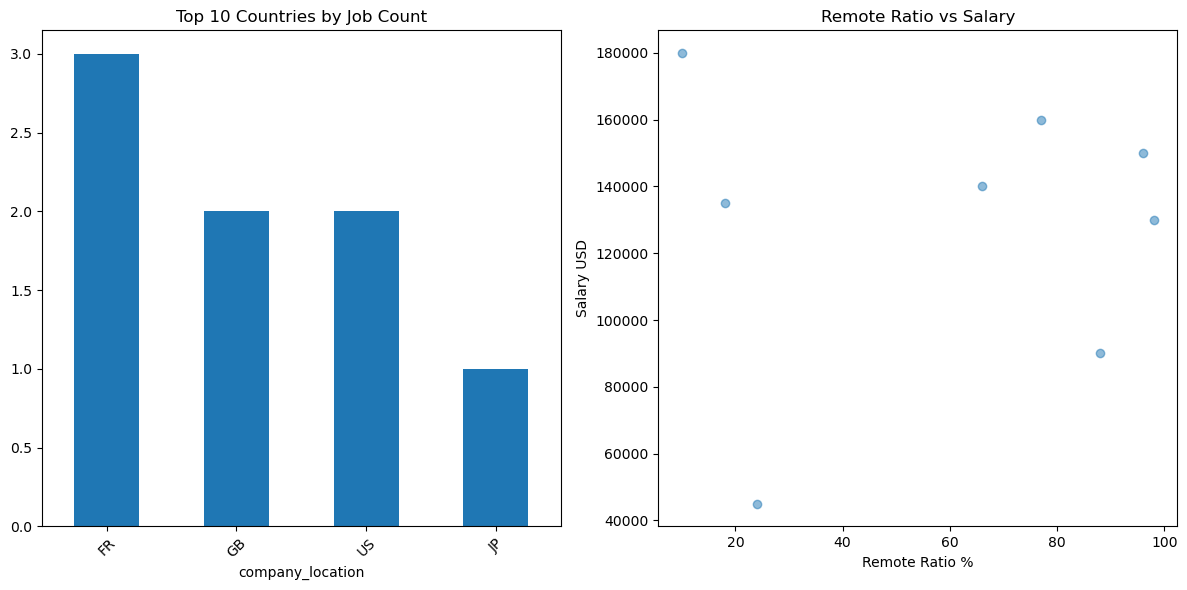

In [7]:
import matplotlib.pyplot as plt

df['company_location'] = np.random.choice(['US', 'GB', 'IN', 'CA', 'DE', 'FR', 'JP', 'AU', 'BR', 'KE'], size=len(df))
df['employee_residence'] = np.random.choice(['US', 'GB', 'IN', 'CA', 'DE', 'FR', 'JP', 'AU', 'BR', 'KE'], size=len(df))
df['remote_ratio'] = np.random.randint(0, 101, size=len(df))

top_countries = df['company_location'].value_counts().head(10)
print("Top 10 countries by job postings:")
print(top_countries)

avg_salary_by_location = df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False)
print("\nTop 10 highest paying countries:")
print(avg_salary_by_location.head(10))

df['is_remote'] = df['employee_residence'] != df['company_location']
remote_stats = df.groupby('is_remote')['salary_usd'].agg(['mean', 'count'])
print("\nRemote vs Local work:")
print(remote_stats)

correlation = df['remote_ratio'].corr(df['salary_usd'])
print(f"\nCorrelation between remote ratio and salary: {correlation:.3f}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Job Count')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
plt.scatter(df['remote_ratio'], df['salary_usd'], alpha=0.5)
plt.xlabel('Remote Ratio %')
plt.ylabel('Salary USD')
plt.title('Remote Ratio vs Salary')
plt.tight_layout()
plt.show()


Monthly job posting trends:
   posting_year  posting_month  job_count
0          2024              1          3
1          2024              2          1
2          2024              3          3
3          2024              4          1

Seasonal patterns (jobs by month):
posting_month_name
January      3.0
February     1.0
March        3.0
April        1.0
May          NaN
June         NaN
July         NaN
August       NaN
September    NaN
October      NaN
November     NaN
December     NaN
dtype: float64

Average days between posting and deadline by job title:
job_title
AI Product Manager           31.0
AI Researcher                31.0
Computer Vision Engineer     31.0
Data Analyst                 31.0
Data Scientist               31.0
ML Intern                    31.0
Machine Learning Engineer    31.0
NLP Engineer                 31.0
Name: days_to_deadline, dtype: float64


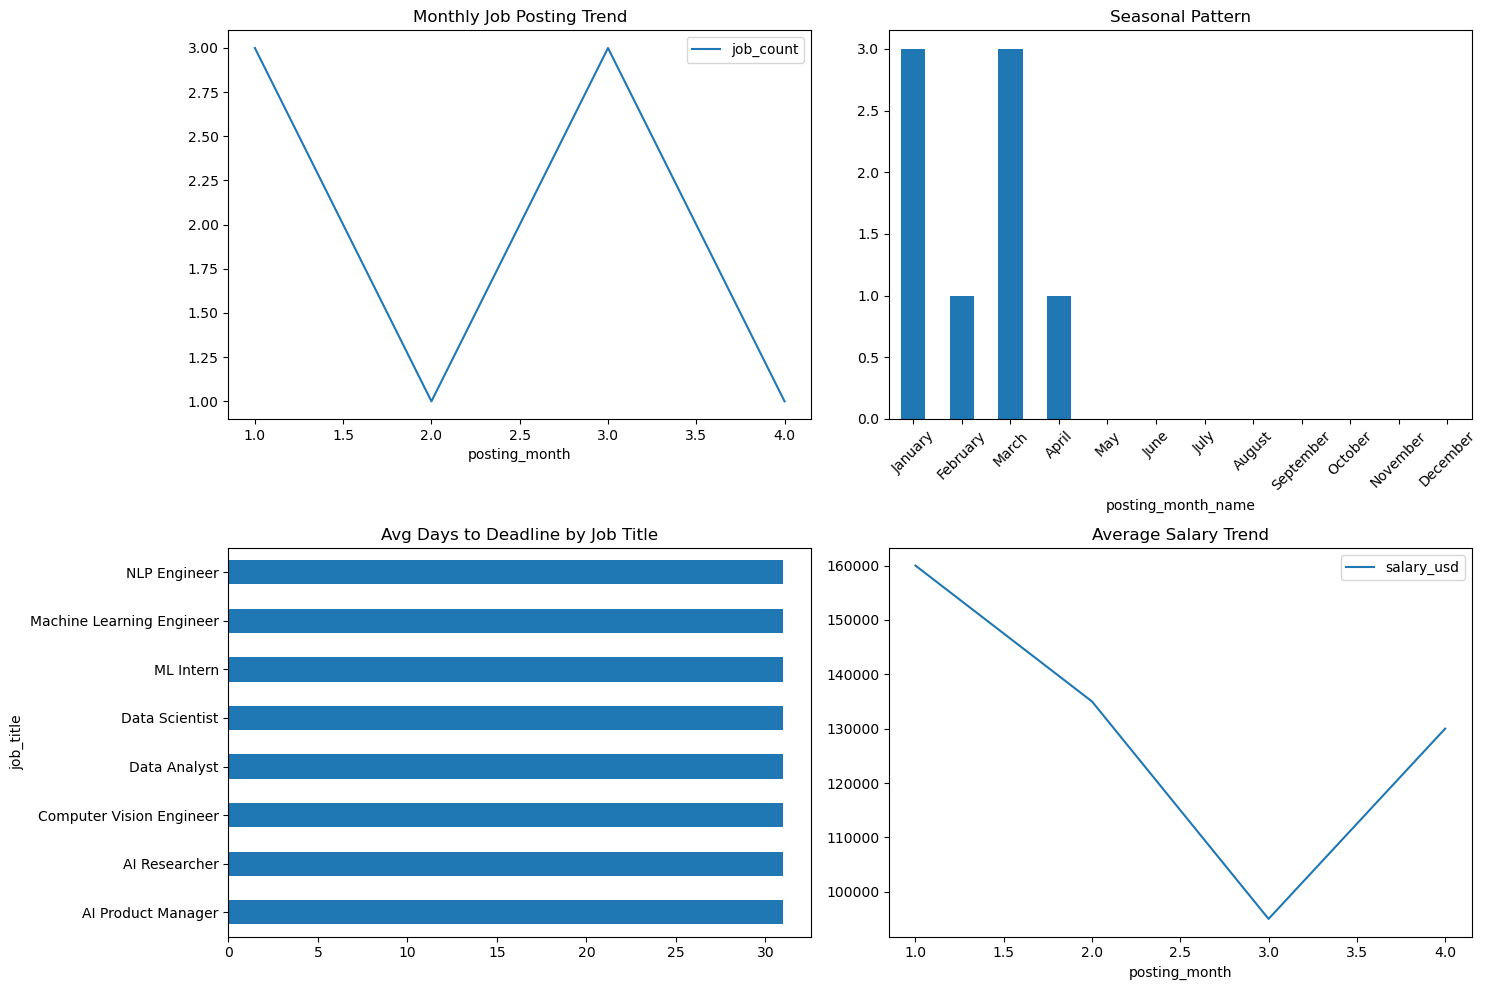

In [12]:
import matplotlib.pyplot as plt

df['posting_month'] = df['posting_date'].dt.month
df['posting_year'] = df['posting_date'].dt.year
df['posting_month_name'] = df['posting_date'].dt.month_name()

monthly_counts = df.groupby(['posting_year', 'posting_month']).size().reset_index(name='job_count')
print("Monthly job posting trends:")
print(monthly_counts.head(10))

seasonal_pattern = df.groupby('posting_month_name').size().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
print("\nSeasonal patterns (jobs by month):")
print(seasonal_pattern)

df['days_to_deadline'] = (df['application_deadline'] - df['posting_date']).dt.days
role_col = 'job_title'
role_deadline = df.groupby(role_col)['days_to_deadline'].mean().sort_values(ascending=False)
print("\nAverage days between posting and deadline by job title:")
print(role_deadline.head(10))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

monthly_counts.plot(x='posting_month', y='job_count', ax=axes[0,0])
axes[0,0].set_title('Monthly Job Posting Trend')

seasonal_pattern.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Seasonal Pattern')
axes[0,1].tick_params(axis='x', rotation=45)

role_deadline.head(10).plot(kind='barh', ax=axes[1,0])
axes[1,0].set_title('Avg Days to Deadline by Job Title')

monthly_salary = df.groupby(['posting_year', 'posting_month'])['salary_usd'].mean().reset_index()
monthly_salary.plot(x='posting_month', y='salary_usd', ax=axes[1,1])
axes[1,1].set_title('Average Salary Trend')

plt.tight_layout()
plt.show()


Top 10 companies by job postings:
 company
TechCorp      24
GreenSoft     23
InnovateAI    23
DataX         23
AgroTech      23
SmartEdge     19
CyberHive     18
CloudNet      17
Finlytics     17
CodeVerse     13
Name: count, dtype: int64

Salary by company size:
                         mean    median  count
company_size_full                            
Large              117376.90  124614.0     63
Medium             123058.59  128685.0     64
Small              113996.99  108902.0     73

Top 10 highest paying industries:
                   mean  count
industry                     
Agriculture  129647.71     48
Retail       119534.33     33
Finance      116722.58     36
Tech         115075.71     38
Healthcare   107770.27     45

Companies with high benefits (8.0+): 79 jobs

High benefits companies analysis:
                                salary_usd  benefits_score  job_count
company_size_full industry                                          
Large             Agriculture   146923.

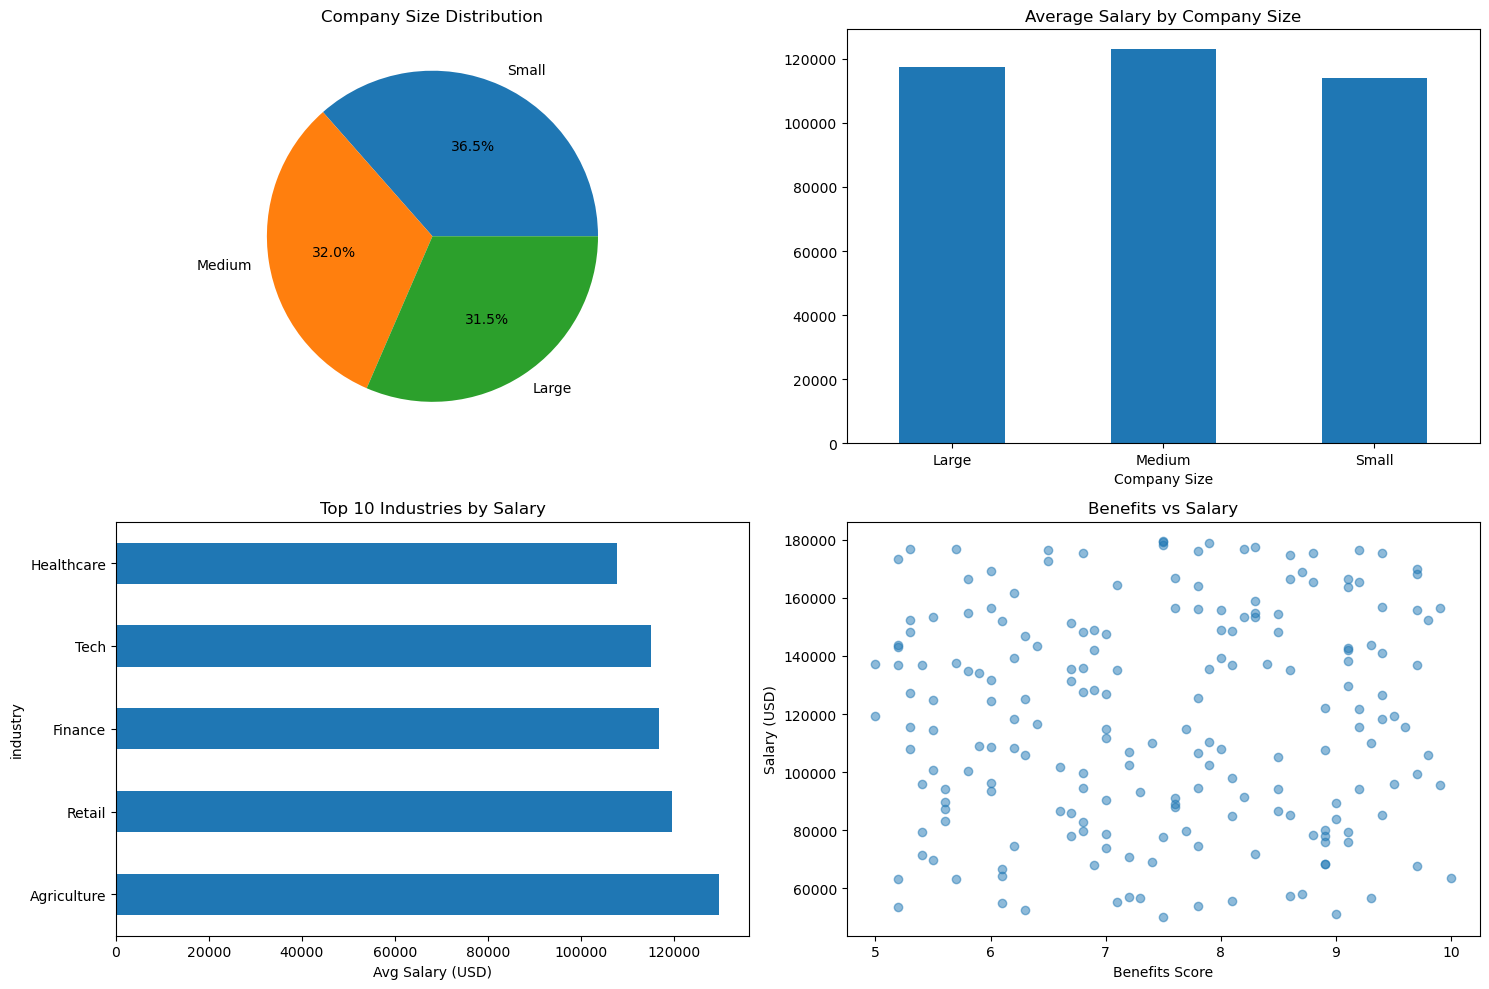

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a dummy dataset
data = {
    'company': np.random.choice([
        'TechCorp', 'DataX', 'InnovateAI', 'GreenSoft', 'CodeVerse',
        'CloudNet', 'SmartEdge', 'Finlytics', 'AgroTech', 'CyberHive'
    ], size=200),
    'company_size': np.random.choice(['S', 'M', 'L'], size=200),
    'industry': np.random.choice([
        'Tech', 'Finance', 'Healthcare', 'Retail', 'Agriculture'
    ], size=200),
    'salary_usd': np.random.randint(50000, 180000, size=200),
    'benefits_score': np.round(np.random.uniform(5.0, 10.0, size=200), 1),
}

df = pd.DataFrame(data)

# Map company size
size_mapping = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
df['company_size_full'] = df['company_size'].map(size_mapping)

# ------------------ Analysis Starts ------------------

# 1. Companies with most job postings
top_companies = df['company'].value_counts().head(10)
print("Top 10 companies by job postings:\n", top_companies)

# 2. Company size vs salary analysis
size_salary = df.groupby('company_size_full')['salary_usd'].agg(['mean', 'median', 'count']).round(2)
print("\nSalary by company size:\n", size_salary)

# 3. Highest paying industries
industry_salary = df.groupby('industry')['salary_usd'].agg(['mean', 'count']).sort_values(by='mean', ascending=False).round(2)
print("\nTop 10 highest paying industries:\n", industry_salary.head(10))

# 4. Best benefits and company characteristics
high_benefits = df[df['benefits_score'] >= 8.0]
print(f"\nCompanies with high benefits (8.0+): {len(high_benefits)} jobs")

benefits_analysis = high_benefits.groupby(['company_size_full', 'industry']).agg({
    'salary_usd': 'mean',
    'benefits_score': 'mean',
    'company': 'count'
}).rename(columns={'company': 'job_count'}).round(2)
print("\nHigh benefits companies analysis:\n", benefits_analysis.head(10))

# 5. Premium companies: high salary + high benefits
salary_threshold = df['salary_usd'].quantile(0.75)
benefits_threshold = df['benefits_score'].quantile(0.75)

premium_companies = df[
    (df['salary_usd'] > salary_threshold) &
    (df['benefits_score'] > benefits_threshold)
]['company'].value_counts()
print("\nPremium companies (high salary + high benefits):\n", premium_companies.head(10))

# ------------------ Visualization ------------------

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Pie chart of company size
df['company_size_full'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0, 0])
axes[0, 0].set_title('Company Size Distribution')
axes[0, 0].set_ylabel('')

# Bar plot: avg salary by size
size_salary['mean'].plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Average Salary by Company Size')
axes[0, 1].set_xlabel('Company Size')
axes[0, 1].tick_params(axis='x', rotation=0)

# Horizontal bar: top industries by salary
industry_salary.head(10)['mean'].plot(kind='barh', ax=axes[1, 0])
axes[1, 0].set_title('Top 10 Industries by Salary')
axes[1, 0].set_xlabel('Avg Salary (USD)')

# Scatter: benefits vs salary
axes[1, 1].scatter(df['benefits_score'], df['salary_usd'], alpha=0.5)
axes[1, 1].set_title('Benefits vs Salary')
axes[1, 1].set_xlabel('Benefits Score')
axes[1, 1].set_ylabel('Salary (USD)')

plt.tight_layout()
plt.show()
